# Step 3 — Data Transformation and Model Training

The objective is to prepare the features, divide the data into training and testing sets, train four regression models and compare their performance.

The dataset is divided into:

- 80% training data
- 20% testing data

All preprocessing is placed inside a scikit-learn Pipeline to prevent data leakage.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use("dark_background")

In [2]:
project_root = Path.cwd().parent
src_path = project_root / "src"


if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from train import (
    load_data,
    split_data,
    get_column_types,
    create_preprocessor,
    train_and_evaluate,
    save_results,
)

In [3]:
dataframe = load_data()

display(dataframe.head())

print("Datatest shape:", dataframe.shape)

Dataset loaded: /home/bsar/Desktop/delivery-eta/data/processed/food_delivery_featured.csv
Dataset shape: (40353, 9)


,Weatherconditions,Road_traffic_density,Type_of_vehicle,City,Time_taken(min),distance_km,order_hour,preparation_time_minutes,distance_group
0,Sunny,High,motorcycle,Urban,24.0,3.025149,11,15.0,Medium (3-7km)
1,Stormy,Jam,scooter,Metropolitian,33.0,20.183530,19,5.0,Long (>7km)
2,Sandstorms,Low,motorcycle,Urban,26.0,1.552758,8,15.0,Short (<3km)
3,Sunny,Medium,motorcycle,Metropolitian,21.0,7.790401,18,10.0,Long (>7km)
4,Cloudy,High,scooter,Metropolitian,30.0,6.210138,13,15.0,Medium (3-7km)


Datatest shape: (40353, 9)


In [4]:
print("Dataset columns:")

for column in dataframe.columns:
    print(f"- {column}")

Dataset columns:
- Weatherconditions
- Road_traffic_density
- Type_of_vehicle
- City
- Time_taken(min)
- distance_km
- order_hour
- preparation_time_minutes
- distance_group


In [5]:
missing_values = (
    dataframe
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_values.to_frame(
        "missing_count"
    )
)

,missing_count
Weatherconditions,0
Road_traffic_density,0
Type_of_vehicle,0
City,0
Time_taken(min),0
distance_km,0
order_hour,0
preparation_time_minutes,0
distance_group,0


In [6]:
X_train, X_test, y_train, y_test = split_data(
    dataframe
)

Training rows: 32282
Testing rows: 8071


In [7]:
split_report = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "Rows":[
        len(X_train),
        len(X_test)
    ],
    "Percentage": [
        len(X_train) / len(dataframe) * 100,
        len(X_test) / len(dataframe) * 100,
    ]
})

display(split_report.round(2))

,Dataset,Rows,Percentage
0,Training,32282,80.0
1,Testing,8071,20.0


## Why split before preprocessing?

The model learns using the training set. The test set remains unseen and represents future deliveries.

The scaler, imputer and encoder must learn only from the training data. If they learn from the test data, data leakage occurs and the model's results become unrealistically optimistic.

In [8]:
numerical_columns, categorical_columns = (
    get_column_types(X_train)
)

print("Numerical columns:")

for column in numerical_columns:
    print(f"- {column}")

print("\nCategorical columns:")

for column in categorical_columns:
    print(f"- {column}")

Numerical columns:
- distance_km
- order_hour
- preparation_time_minutes

Categorical columns:
- Weatherconditions
- Road_traffic_density
- Type_of_vehicle
- City
- distance_group


In [9]:
preprocessor = create_preprocessor(
    X_train
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [10]:
results, trained_pipelines = train_and_evaluate(
    X_train,
    X_test,
    y_train,
    y_test,
    preprocessor
)

Training Linear Regression...
Training Ridge Regression...
Training Decision Tree...
Training Random Forest...


In [11]:
display(
    results.round(3)
)

,Model,Train_MAE,Test_MAE,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Train_R2,Test_R2
0,Random Forest,2.090,5.528,7.412,50.875,2.723,7.133,0.916,0.422
1,Linear Regression,6.051,6.017,56.419,55.956,7.511,7.480,0.357,0.364
2,Ridge Regression,6.051,6.017,56.419,55.956,7.511,7.480,0.357,0.364
3,Decision Tree,0.097,7.047,0.588,84.275,0.767,9.180,0.993,0.042


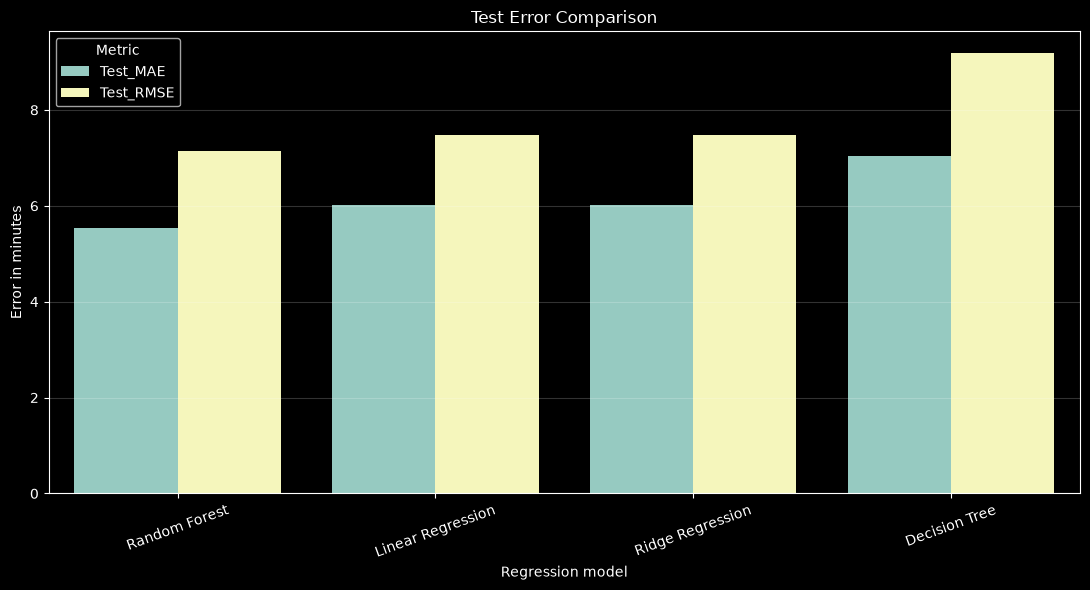

In [12]:
metrics_long = results.melt(
    id_vars="Model",
    value_vars=[
        "Test_MAE",
        "Test_RMSE",
    ],
    var_name="Metric",
    value_name="Error"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=metrics_long,
    x="Model",
    y="Error",
    hue="Metric"
)

plt.title("Test Error Comparison")
plt.xlabel("Regression model")
plt.ylabel("Error in minutes")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

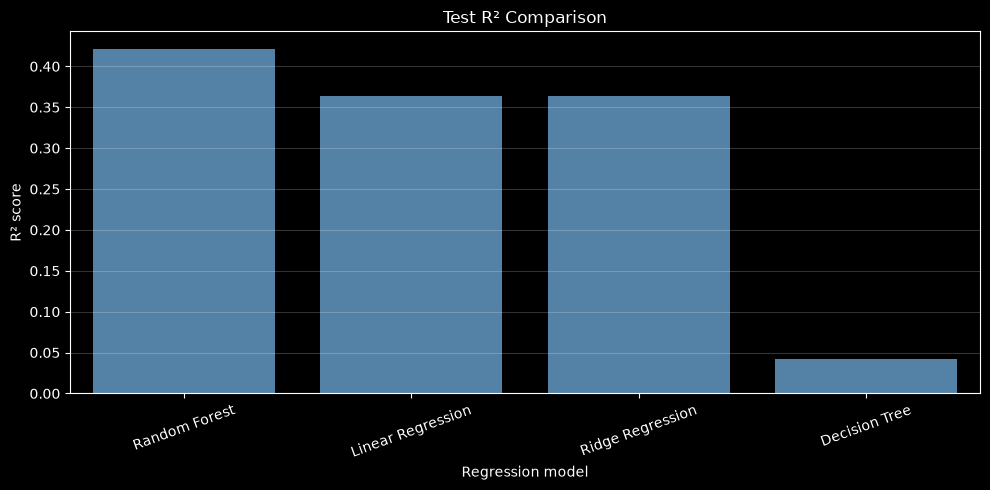

In [13]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Test_R2",
    color="steelblue"
)

plt.title("Test R² Comparison")
plt.xlabel("Regression model")
plt.ylabel("R² score")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

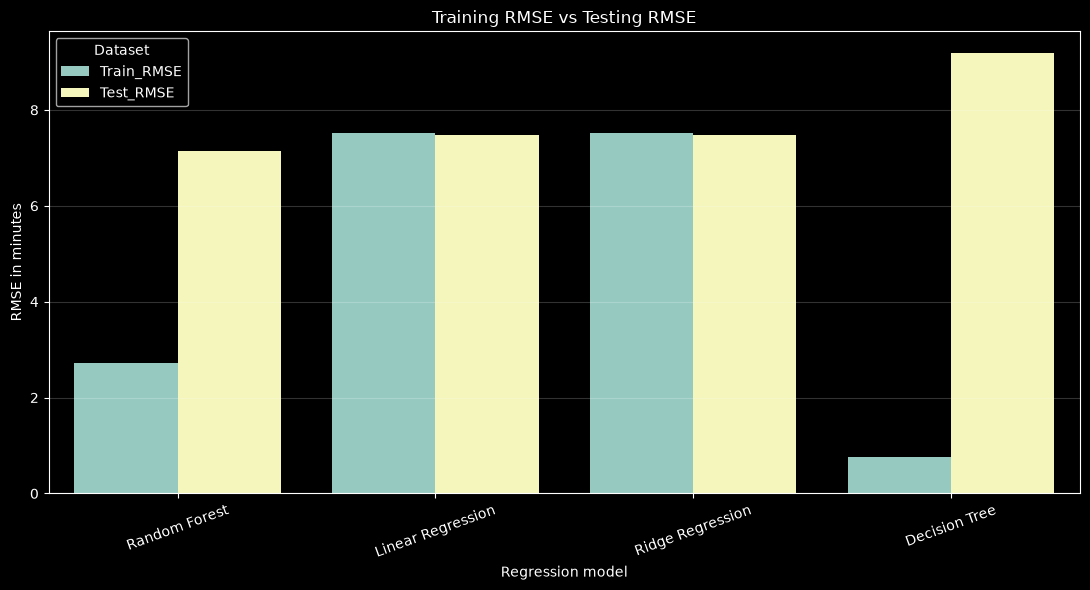

In [14]:
rmse_comparison = results.melt(
    id_vars="Model",
    value_vars=[
        "Train_RMSE",
        "Test_RMSE",
    ],
    var_name="Dataset",
    value_name="RMSE"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=rmse_comparison,
    x="Model",
    y="RMSE",
    hue="Dataset"
)

plt.title("Training RMSE vs Testing RMSE")
plt.xlabel("Regression model")
plt.ylabel("RMSE in minutes")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [15]:
best_model_name = results.loc[
    0,
    "Model"
]

best_pipeline = trained_pipelines[
    best_model_name
]

print("Best baseline model:", best_model_name)

Best baseline model: Random Forest


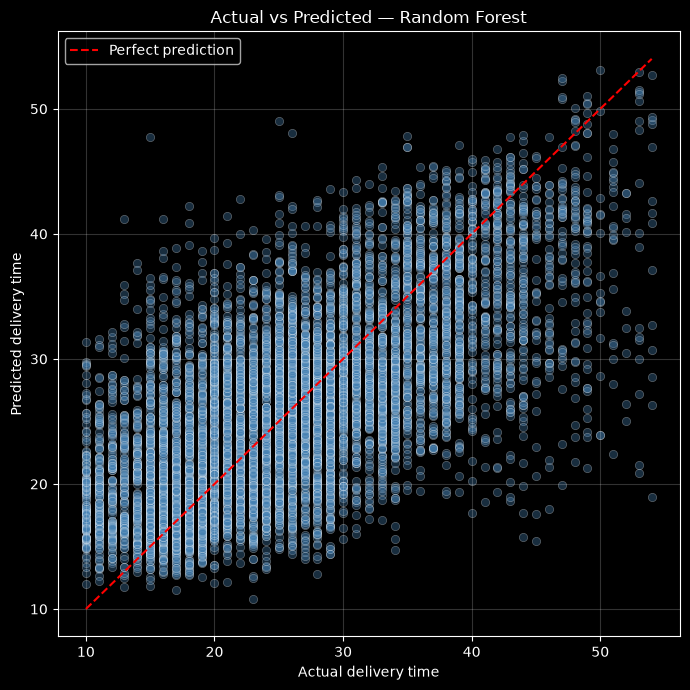

In [16]:
test_predictions = best_pipeline.predict(
    X_test
)

plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=y_test,
    y=test_predictions,
    alpha=0.35,
    color="steelblue"
)

minimum_value = min(
    y_test.min(),
    test_predictions.min()
)

maximum_value = max(
    y_test.max(),
    test_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.title(
    f"Actual vs Predicted — {best_model_name}"
)
plt.xlabel("Actual delivery time")
plt.ylabel("Predicted delivery time")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [17]:
best_result = results.iloc[0]

print(
    f"The best baseline model is "
    f"{best_result['Model']}."
)

print(
    f"It makes an average error of approximately "
    f"{best_result['Test_MAE']:.2f} minutes."
)

print(
    f"Its RMSE is "
    f"{best_result['Test_RMSE']:.2f} minutes."
)

print(
    f"Its R² score is "
    f"{best_result['Test_R2']:.3f}."
)

The best baseline model is Random Forest.
It makes an average error of approximately 5.53 minutes.
Its RMSE is 7.13 minutes.
Its R² score is 0.422.


In [18]:
saved_model_name, saved_pipeline = save_results(
    results,
    trained_pipelines
)

Best baseline model: Random Forest
Results saved to: /home/bsar/Desktop/delivery-eta/models/model_comparison.csv
Pipeline saved to: /home/bsar/Desktop/delivery-eta/models/best_baseline_pipeline.joblib
